# Task 1: Analyze a COVID-19 Dataset

## Import libraries

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [2]:
df = pd.read_csv("full_grouped.csv")

In [3]:
df

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
35151,2020-07-27,West Bank and Gaza,10621,78,3752,6791,152,2,0,Eastern Mediterranean
35152,2020-07-27,Western Sahara,10,1,8,1,0,0,0,Africa
35153,2020-07-27,Yemen,1691,483,833,375,10,4,36,Eastern Mediterranean
35154,2020-07-27,Zambia,4552,140,2815,1597,71,1,465,Africa


## Explore the data

In [10]:
df.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            35156 non-null  datetime64[ns]
 1   Country/Region  35156 non-null  object        
 2   Confirmed       35156 non-null  int64         
 3   Deaths          35156 non-null  int64         
 4   Recovered       35156 non-null  int64         
 5   Active          35156 non-null  int64         
 6   New cases       35156 non-null  int64         
 7   New deaths      35156 non-null  int64         
 8   New recovered   35156 non-null  int64         
 9   WHO Region      35156 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(2)
memory usage: 2.7+ MB


In [19]:
df.shape

(35156, 10)

In [20]:
df.columns

Index(['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'WHO Region'],
      dtype='object')

In [12]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered
count,3.515600e+04,35156.000000,3.515600e+04,3.515600e+04,35156.00000,35156.000000,35156.000000
mean,2.356663e+04,1234.068239,1.104813e+04,1.128443e+04,469.36375,18.603339,269.315593
std,1.499818e+05,7437.238354,6.454640e+04,8.997149e+04,3005.86754,115.706351,2068.063852
min,0.000000e+00,0.000000,0.000000e+00,-2.000000e+00,0.00000,-1918.000000,-16298.000000
25%,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000
50%,2.500000e+02,4.000000,3.300000e+01,8.500000e+01,2.00000,0.000000,0.000000
75%,3.640250e+03,78.250000,1.286250e+03,1.454000e+03,75.00000,1.000000,20.000000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,77255.00000,3887.000000,140050.000000


## Clean the data
- Remove duplicates
- Handle missing values
- Convert Date column to datetime

In [40]:
df.isnull().sum()

Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
New cases         0
New deaths        0
New recovered     0
WHO Region        0
dtype: int64

In [ ]:
df.duplicated.su

In [21]:
df.drop_duplicates(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])

## Total Cases by Date

In [23]:
daily = df.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

In [24]:
daily

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,555,17,28,510
1,2020-01-23,654,18,30,606
2,2020-01-24,941,26,36,879
3,2020-01-25,1434,42,39,1353
4,2020-01-26,2118,56,52,2010
...,...,...,...,...,...
183,2020-07-23,15510481,633506,8710969,6166006
184,2020-07-24,15791645,639650,8939705,6212290
185,2020-07-25,16047190,644517,9158743,6243930
186,2020-07-26,16251796,648621,9293464,6309711


# Data Visualization

## Daily Confirmed Cases

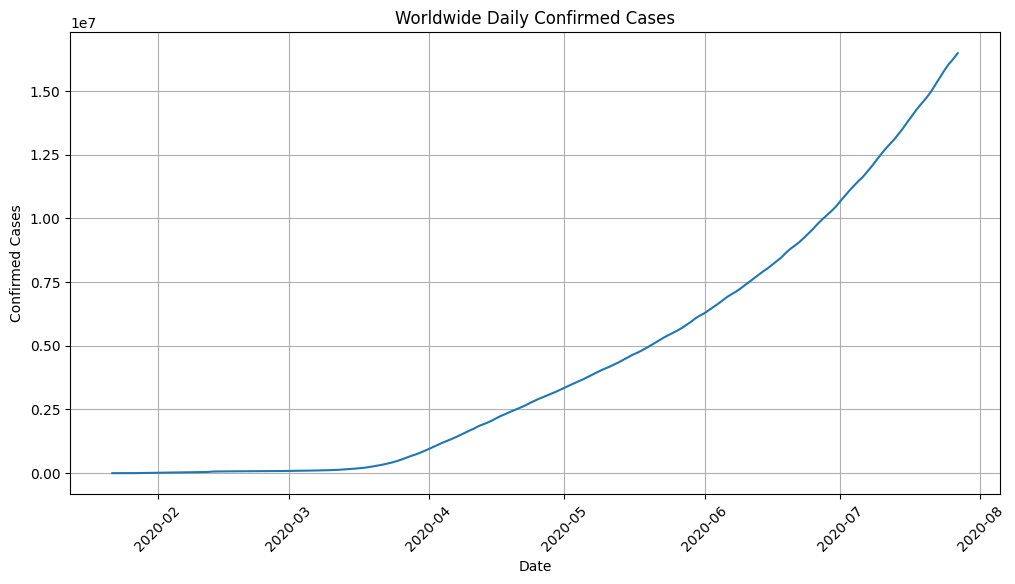

In [38]:
plt.figure(figsize=(12,6))
plt.plot(daily['Date'], daily['Confirmed'])
plt.title("Worldwide Daily Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

## Daily Death Cases

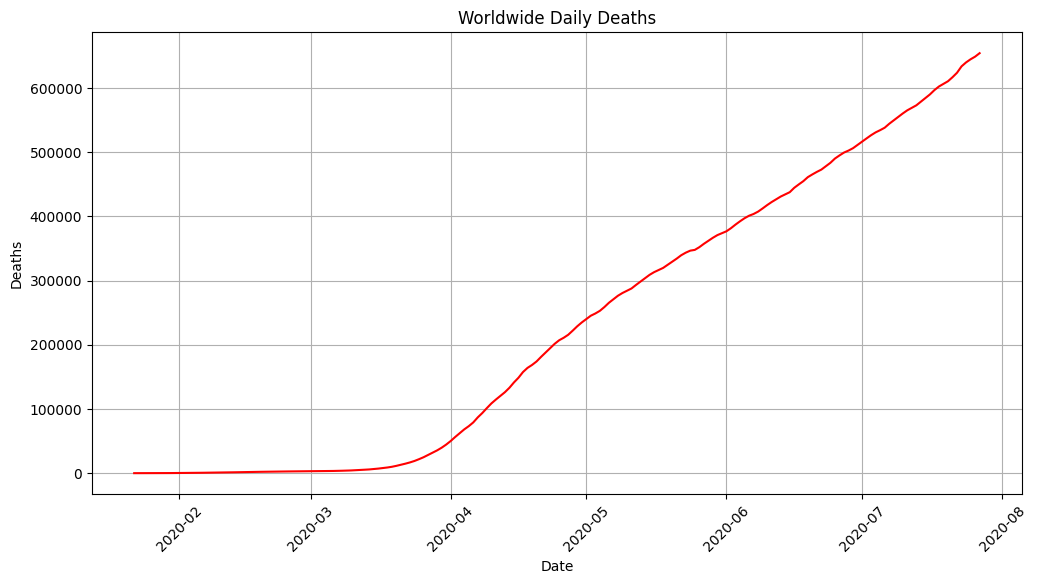

In [26]:
plt.figure(figsize=(12,6))
plt.plot(daily['Date'], daily['Deaths'], color='red')
plt.title("Worldwide Daily Deaths")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Daily Recovery Trend

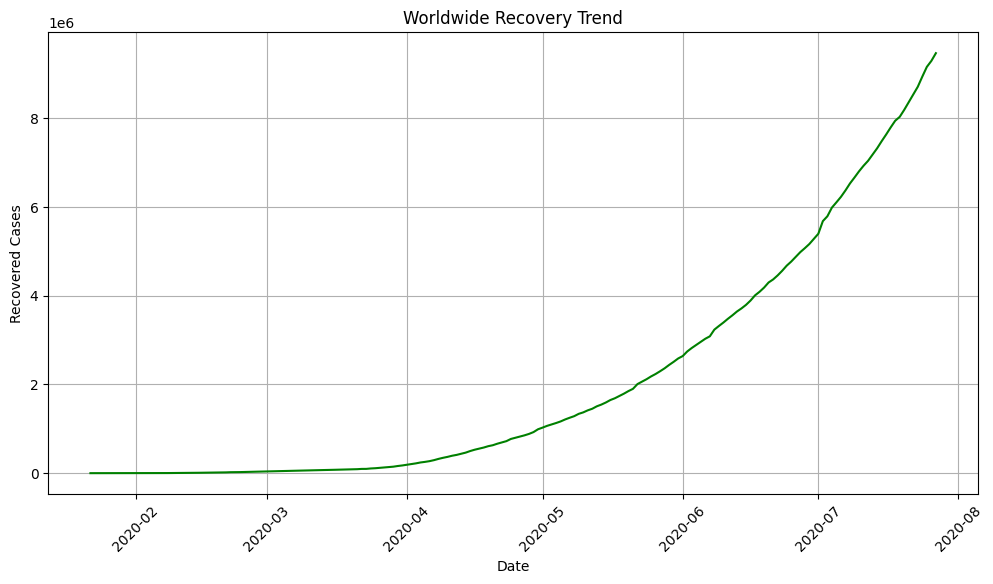

In [27]:
plt.figure(figsize=(12,6))
plt.plot(daily['Date'], daily['Recovered'], color='green')
plt.title("Worldwide Recovery Trend")
plt.xlabel("Date")
plt.ylabel("Recovered Cases")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Active Cases

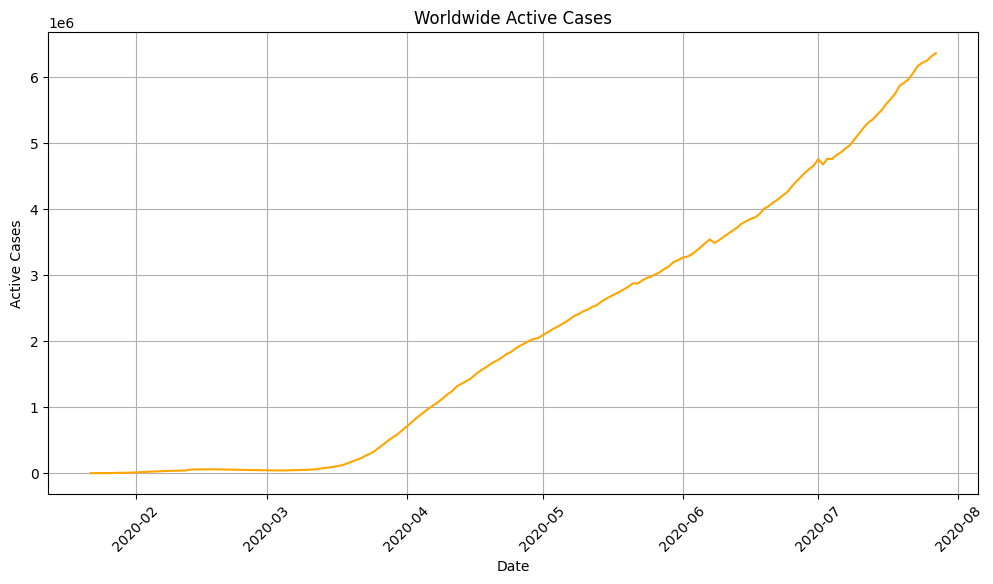

In [28]:
plt.figure(figsize=(12,6))
plt.plot(daily['Date'], daily['Active'], color='orange')
plt.title("Worldwide Active Cases")
plt.xlabel("Date")
plt.ylabel("Active Cases")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Top 10 Countries by Confirmed Cases

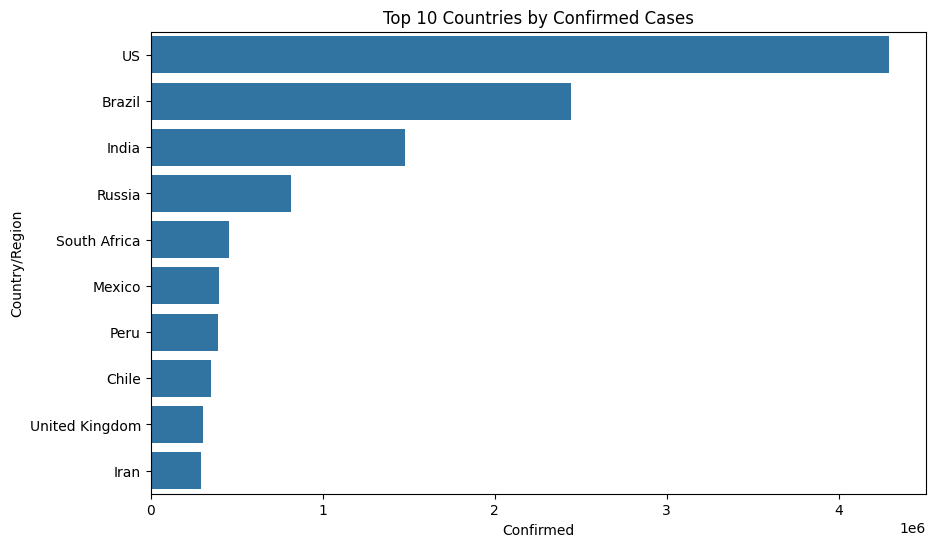

In [29]:
latest = df[df['Date'] == df['Date'].max()]

top10 = latest.sort_values(by='Confirmed', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Confirmed', y='Country/Region', data=top10)
plt.title("Top 10 Countries by Confirmed Cases")
plt.show()

## Top 10 Countries by Deaths

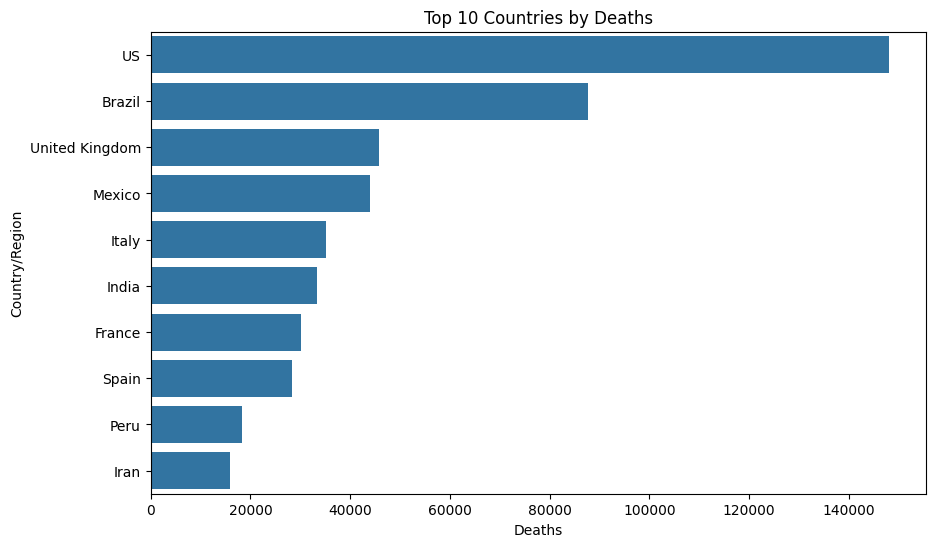

In [30]:
top10_deaths = latest.sort_values(by='Deaths', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Deaths', y='Country/Region', data=top10_deaths)
plt.title("Top 10 Countries by Deaths")
plt.show()

##  Top 10 Countries by Recoveries

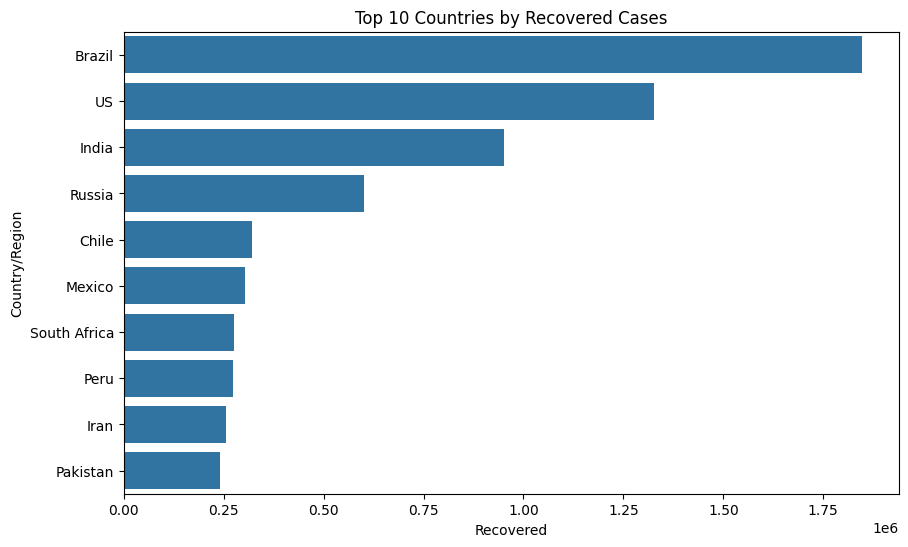

In [31]:
top10_recovered = latest.sort_values(by='Recovered', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Recovered', y='Country/Region', data=top10_recovered)
plt.title("Top 10 Countries by Recovered Cases")
plt.show()

## Pie Chart
# Top 5 Countries

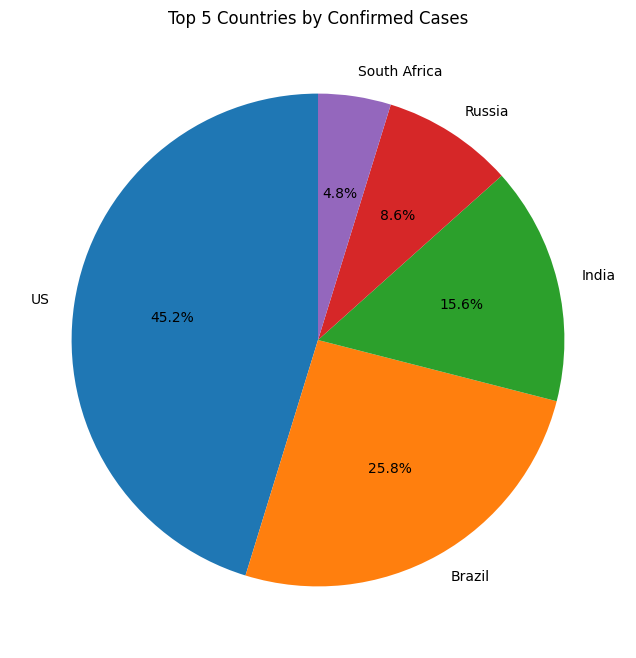

In [32]:
top5 = latest.sort_values(by='Confirmed', ascending=False).head(5)

plt.figure(figsize=(8,8))
plt.pie(top5['Confirmed'],
        labels=top5['Country/Region'],
        autopct='%1.1f%%',
        startangle=90)
plt.title("Top 5 Countries by Confirmed Cases")
plt.show()

## Correlation Heatmap

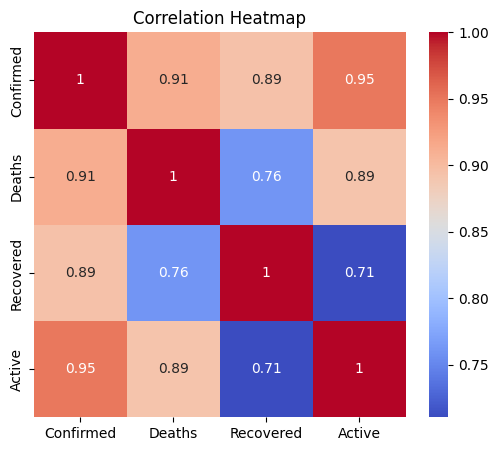

In [33]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['Confirmed','Deaths','Recovered','Active']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Histogram

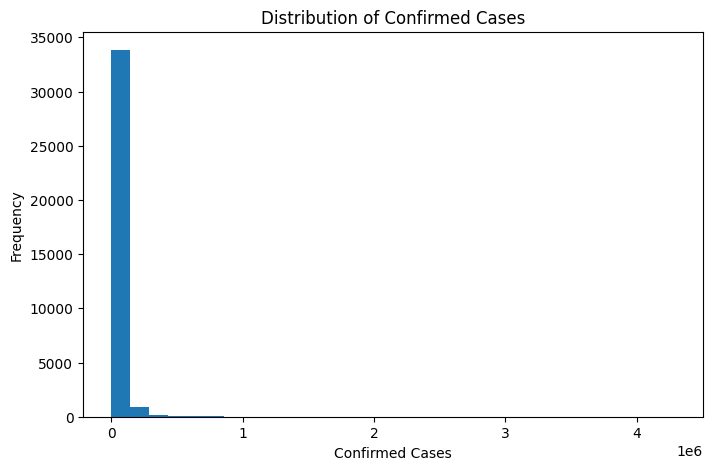

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df['Confirmed'], bins=30)
plt.title("Distribution of Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Frequency")
plt.show()

## Box Plot

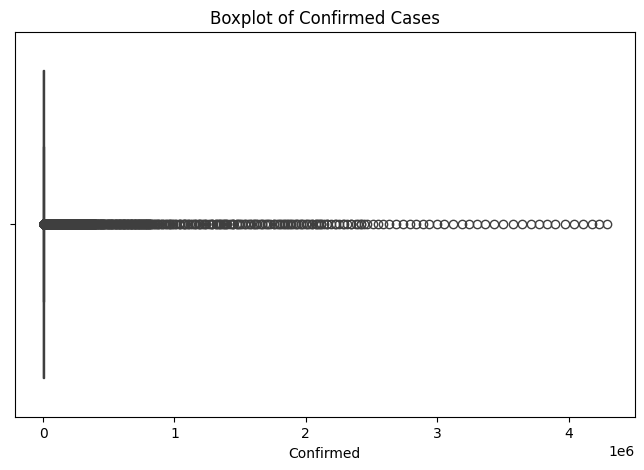

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Confirmed'])
plt.title("Boxplot of Confirmed Cases")
plt.show()

##  Final Summary

In [36]:
print("\nTotal Confirmed Cases :", daily['Confirmed'].iloc[-1])
print("Total Deaths          :", daily['Deaths'].iloc[-1])
print("Total Recovered       :", daily['Recovered'].iloc[-1])
print("Total Active Cases    :", daily['Active'].iloc[-1])


Total Confirmed Cases : 16480485
Total Deaths          : 654036
Total Recovered       : 9468087
Total Active Cases    : 6358362
